In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Install required libraries, upgrading wfdb and ensuring compatible numpy
!pip install --upgrade --no-cache-dir wfdb PyWavelets scipy matplotlib 'numpy==1.26.0' 'pandas==2.2.2'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.


In [ ]:
!wget -r -N -c -np https://physionet.org/files/mitdb/1.0.0/
!mv physionet.org/files/mitdb/1.0.0 /content/mitbih

Streaming output truncated to the last 5000 lines.
Length: 5468 (5.3K) [application/octet-stream]
Saving to: ‘physionet.org/files/mitdb/1.0.0/223.atr’

physionet.org/files 100%[===================>]   5.34K  --.-KB/s    in 0s      

2026-02-02 02:21:39 (1.10 GB/s) - ‘physionet.org/files/mitdb/1.0.0/223.atr’ saved [5468/5468]

--2026-02-02 02:21:39--  https://physionet.org/files/mitdb/1.0.0/223.dat
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1950000 (1.9M) [application/octet-stream]
Saving to: ‘physionet.org/files/mitdb/1.0.0/223.dat’

physionet.org/files 100%[===================>]   1.86M   382KB/s    in 4.9s    

2026-02-02 02:21:45 (386 KB/s) - ‘physionet.org/files/mitdb/1.0.0/223.dat’ saved [1950000/1950000]

--2026-02-02 02:21:45--  https://physionet.org/files/mitdb/1.0.0/223.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 258 [text/plain]
Saving to: ‘physionet.

In [ ]:
import os
print("MIT-BIH files count:", len(os.listdir('/content/mitbih')))

MIT-BIH files count: 208


1. **Loading Raw Dataset**

This code loads a raw ECG recording from the MIT-BIH Arrhythmia Database using the rdsamp() function. It extracts the MLII lead signal, which is the primary channel used for arrhythmia analysis. The shape of the ECG signal is printed to confirm successful loading. Finally, the first 2000 samples of the raw ECG waveform are plotted to visualize the unprocessed signal before applying any preprocessing steps

Raw ECG shape: (650000,)


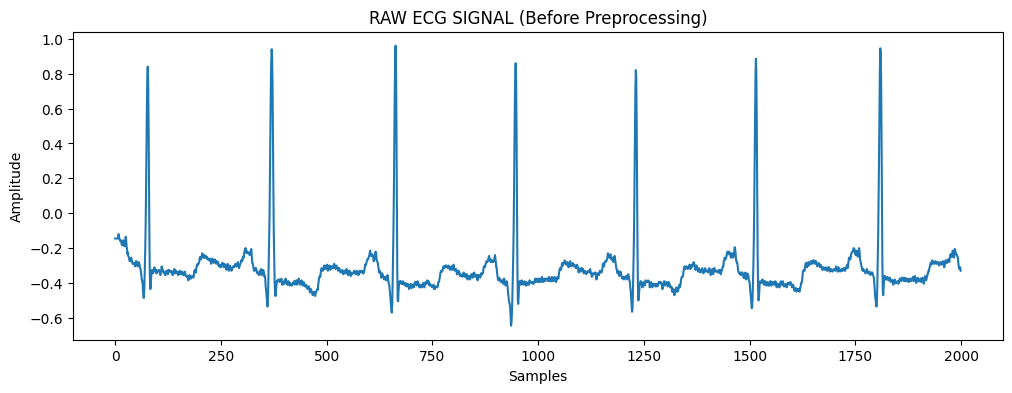

In [ ]:
from wfdb import rdsamp
import matplotlib.pyplot as plt
import numpy as np

signal, fields = rdsamp('/content/mitbih/100')
ecg = signal[:,0]   # MLII channel

print("Raw ECG shape:", ecg.shape)

# ---- BEFORE plot ----
plt.figure(figsize=(12,4))
plt.plot(ecg[:2000])
plt.title("RAW ECG SIGNAL (Before Preprocessing)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

2 . **Wavelet Denoising** :
This code performs wavelet-based denoising on the raw ECG signal using a Daubechies-4 (db4) wavelet with four levels of decomposition. High-frequency noise components are removed by zeroing the detail coefficients, and the signal is then reconstructe


ECG signal has different speeds of changes:

• Slow changes → P wave and T wave

• Medium changes → QRS complex

• Very fast changes → noise

db4 -> captures heartbeat features and separates noise effectively.

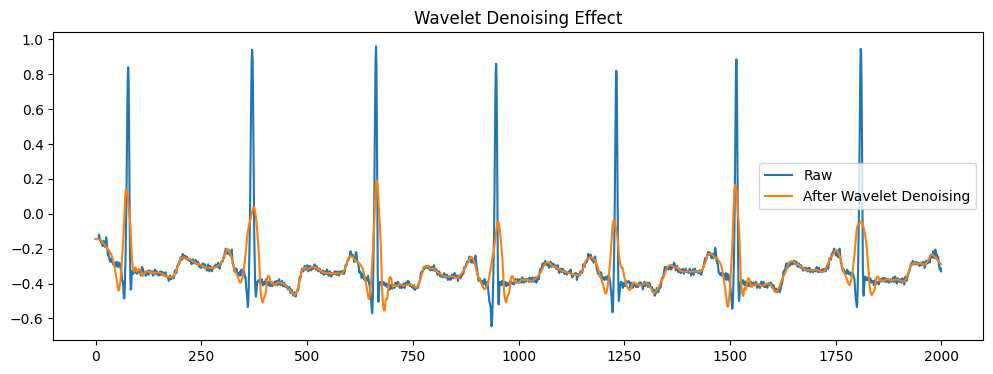

In [ ]:
import pywt

def wavelet_denoise(sig):
    coeffs = pywt.wavedec(sig, 'db4', level=4)
    coeffs[1:] = [np.zeros_like(c) for c in coeffs[1:]]  # remove high freq noise
    rec = pywt.waverec(coeffs, 'db4')
    return rec[:len(sig)]

denoised = wavelet_denoise(ecg)

# ---- BEFORE vs AFTER ----
plt.figure(figsize=(12,4))
plt.plot(ecg[:2000], label="Raw")
plt.plot(denoised[:2000], label="After Wavelet Denoising")
plt.legend()
plt.title("Wavelet Denoising Effect")
plt.show()


**Wavelet Threshold Denoising**

Wavelet threshold denoising reduces high-frequency noise in the ECG signal by decomposing it using a db4 wavelet and selectively shrinking noisy components instead of removing them completely. The signal is then reconstructed, preserving important heartbeat features such as the QRS complex while producing a cleaner waveform for further processing.

Why Wavelet Threshold Denoising Instead of Basic Wavelet Denoising?

Wavelet threshold denoising is preferred over basic wavelet denoising because it reduces only the noisy components instead of completely removing high-frequency details, which can distort important ECG features. This approach better preserves the morphology of heartbeat waves, especially the QRS complex, while still effectively reducing noise.

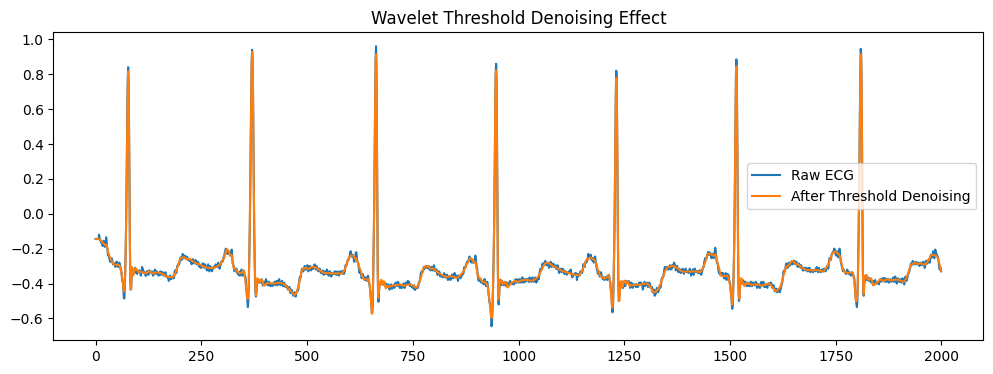

In [ ]:
# ============================================================
# STEP — Wavelet Denoising using Thresholding
# ============================================================

import pywt
import numpy as np
import matplotlib.pyplot as plt

def wavelet_denoise_threshold(sig, wavelet='db4', level=4):
    coeffs = pywt.wavedec(sig, wavelet, level=level)

    # Estimate noise threshold
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(sig)))

    # Apply soft thresholding
    new_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        new_coeffs.append(pywt.threshold(c, threshold, mode='soft'))

    rec = pywt.waverec(new_coeffs, wavelet)
    return rec[:len(sig)]

denoised = wavelet_denoise_threshold(ecg)

# ---- BEFORE vs AFTER ----
plt.figure(figsize=(12,4))
plt.plot(ecg[:2000], label="Raw ECG")
plt.plot(denoised[:2000], label="After Threshold Denoising")
plt.legend()
plt.title("Wavelet Threshold Denoising Effect")
plt.show()


3. **Baseline Drift Removal (IIR Zero-phase filter)** : This code removes baseline drift from the denoised ECG signal using a high-pass Butterworth IIR filter with zero-phase filtering. The filter suppresses low-frequency variations caused by respiration and electrode movement while preserving the main ECG waveform

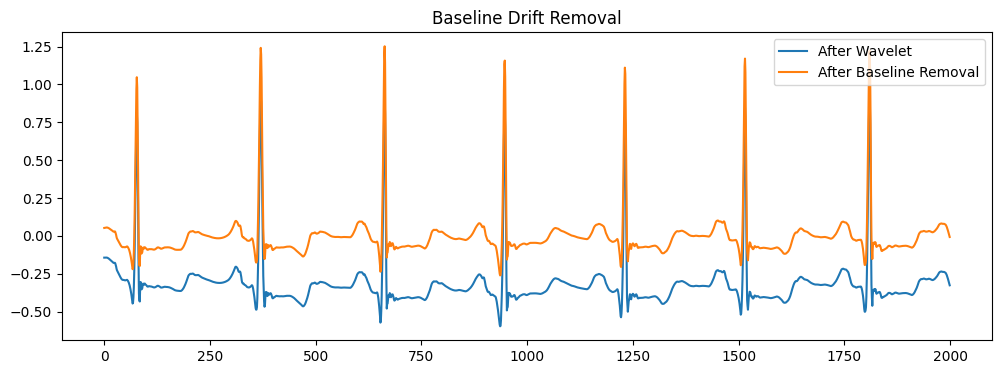

In [ ]:
from scipy.signal import butter, filtfilt

def remove_baseline(sig, fs=360):
    b, a = butter(2, 0.5/(fs/2), btype='highpass')
    return filtfilt(b, a, sig)

baseline_corrected = remove_baseline(denoised)

# ---- BEFORE vs AFTER ----
plt.figure(figsize=(12,4))
plt.plot(denoised[:2000], label="After Wavelet")
plt.plot(baseline_corrected[:2000], label="After Baseline Removal")
plt.legend()
plt.title("Baseline Drift Removal")
plt.show()


4. **R-Peak Detection (using MIT-BIH annotations)** : This code loads the annotation file associated with the ECG record from the MIT-BIH dataset and extracts the sample indices of R-peaks, which were originally detected. These R-peak locations represent the positions of QRS complexes in the ECG signal and are used as reference points for heartbeat segmentation in later preprocessing steps.

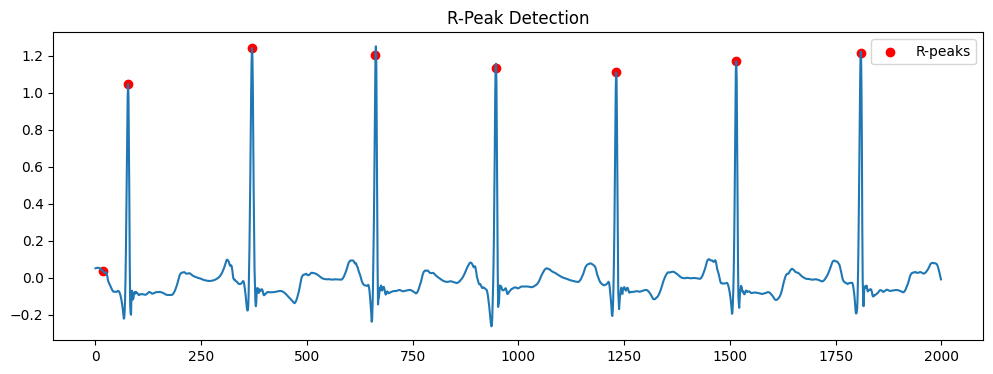

In [ ]:
from wfdb import rdann
import matplotlib.pyplot as plt

ann = rdann('/content/mitbih/100', 'atr')
r_peaks = ann.sample

# ---- Plot R-peaks ----
plt.figure(figsize=(12,4))
plt.plot(baseline_corrected[:2000])
plt.scatter(r_peaks[r_peaks<2000],
            baseline_corrected[r_peaks[r_peaks<2000]],
            color='red', label="R-peaks")
plt.legend()
plt.title("R-Peak Detection")
plt.show()

5. **Heartbeat Segmentation (0.75s window = 270 samples)** : This code segments individual heartbeats from the baseline-corrected ECG signal using the detected R-peak locations as reference points. For each R-peak, a fixed window of 270 samples (corresponding to 0.75 seconds at a 360 Hz sampling rate) is extracted, ensuring that each segment contains one complete heartbeat cycle. The collected heartbeat segments are stored as a NumPy array to form the input samples for further normalization and model training.

Segmented heartbeats shape: (2271, 270)


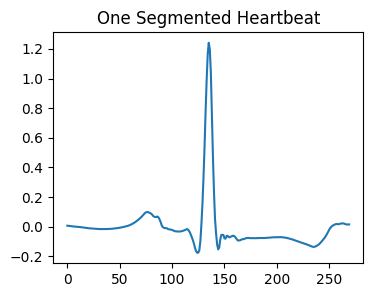

In [ ]:
segments = []
for r in r_peaks:
    start = r - 135
    end = r + 135
    if start >= 0 and end < len(baseline_corrected):
        segments.append(baseline_corrected[start:end])

segments = np.array(segments)
print("Segmented heartbeats shape:", segments.shape)

# ---- Plot one heartbeat ----
plt.figure(figsize=(4,3))
plt.plot(segments[0])
plt.title("One Segmented Heartbeat")
plt.show()


6. **Normalization (0–1 Min-Max Scaling)**

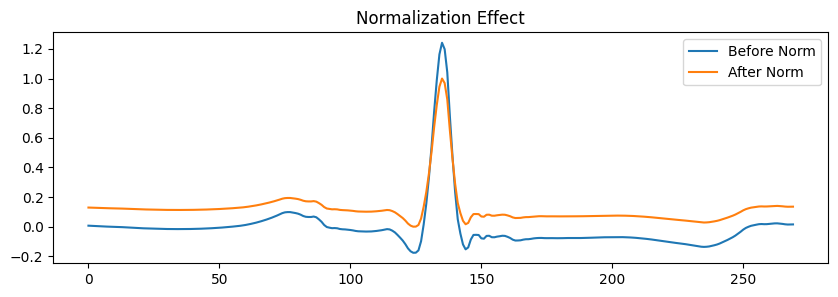

In [ ]:
def normalize(sig):
    return (sig - np.min(sig)) / (np.max(sig) - np.min(sig))

normalized_segments = np.array([normalize(s) for s in segments])

# ---- BEFORE vs AFTER ----
plt.figure(figsize=(10,3))
plt.plot(segments[0], label="Before Norm")
plt.plot(normalized_segments[0], label="After Norm")
plt.legend()
plt.title("Normalization Effect")
plt.show()

**Z-score Normalization**

Z-score normalization standardizes each heartbeat segment by subtracting its mean and dividing by its standard deviation, centering the signal around zero while maintaining waveform variations. This provides consistent scaling across samples and improves stability during model training.

Z-score normalization is preferred over Min–Max normalization because it centers heartbeat signals around zero while preserving both positive and negative variations, which are important in ECG analysis. It also provides better training stability for neural networks, whereas Min–Max scaling can compress useful signal variations and is more sensitive to outliers.

Normalized segments shape: (2271, 270)


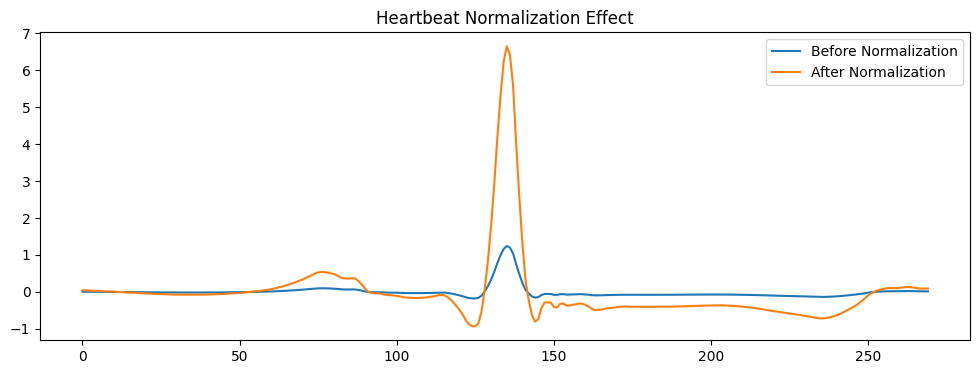

In [ ]:
# ============================================================
# STEP — Z-score Normalization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# segments shape: (num_beats, 270)

mean = np.mean(segments, axis=1, keepdims=True)
std = np.std(segments, axis=1, keepdims=True)

normalized_segments = (segments - mean) / (std + 1e-8)

print("Normalized segments shape:", normalized_segments.shape)

# ---- BEFORE vs AFTER ----
plt.figure(figsize=(12,4))
plt.plot(segments[0], label="Before Normalization")
plt.plot(normalized_segments[0], label="After Normalization")
plt.legend()
plt.title("Heartbeat Normalization Effect")
plt.show()


In [ ]:
np.save("ecg_preprocessed.npy", normalized_segments)
print("Saved file: ecg_preprocessed.npy")
print("Final dataset shape:", normalized_segments.shape)

Saved file: ecg_preprocessed.npy
Final dataset shape: (2271, 270)


| Step             | Current | Better Option  | Worth Changing?     |
| ---------------- | ------- | -------------- | ------------------- |
| Wavelet denoise  | Good    | Thresholding   | Not so neccesary and thresholding takes a bit more computation           |
| Baseline removal | Good    | Wavelet/Median | Optional            |
| R-peak detection | Perfect | Pan-Tompkins   | Not necessary |
| Segmentation     | Good    | RR adaptive    | Not needed          |
| Normalization    | Good    | Z-score        | better       |
